# Linear Regression:
`Linear Regression` is a supervised machine learning algorthim where the predicted output is `continuous` and has a `constant slope`. It's used to predict values within a `continuous range`, (e.g sales, price,  ) rather than to classify them into categories (e.g cat , dog) . 
There are two main types:

- **Simple Linear Regression** -Only one independent variable(e.g sales)
- **Mutliple Linear Regression** - more than one independent variables (e.g sales, price)

In [ ]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# load the data
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='tip'>

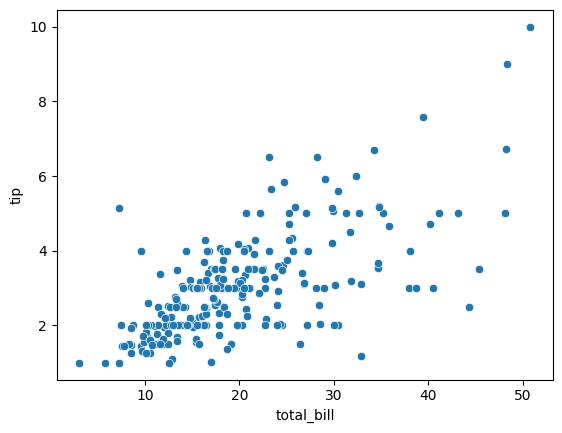

In [3]:
sns.scatterplot(x='total_bill', y='tip', data= df)

In [ ]:
# split the data into x and y
X = df[['total_bill']]
y = df['tip']

In [5]:
# split the data into train and test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [6]:
# call the model
model = LinearRegression()

In [7]:
# train the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.1]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['total_bill']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.931
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [ ]:
# take out model intercept and slop, make an equation
print(model.intercept_)
print(model.coef_)
print('y = ', model.intercept_,  '+' , model.coef_ , '* X')

0.9310431375396124
[0.10430149]
y =  0.9310431375396124 + [0.10430149] * X


In [22]:
# prediction
y_predict = model.predict(X_test)
y_predict

array([2.62802838, 4.31041142, 2.14198344, 2.47261916, 2.75214716,
       4.06634593, 2.63011441, 1.71434733, 3.04523435, 4.36256217,
       2.63324346, 1.80196058, 3.86921612, 4.56386404, 4.54508978,
       2.83767438, 2.41838239, 2.59778095, 2.69686737, 2.18474705,
       4.56177801, 4.35526106, 2.59986698, 2.13989741, 2.64471662,
       2.96387918, 3.40090243, 3.08904097, 2.81264202, 3.48851568,
       5.96567607, 3.70441976, 2.80012584, 3.09634208, 2.62177029,
       1.53077671, 2.7969968 , 2.26193015, 3.29555792, 2.11486505,
       5.04260788, 2.70103943, 3.76595764, 1.96779995, 3.44262302,
       2.03976798, 3.77638779, 2.46740409, 2.28696251])

In [15]:
# evaluate the model
print('MSE', mean_squared_error(y_test, y_predict))
print('R2', r2_score(y_test, y_predict))
print('RMSE', np.sqrt(mean_squared_error(y_test, y_predict)))

MSE 1.101961406831195
R2 0.4601223162458986
RMSE 1.0497434957317882


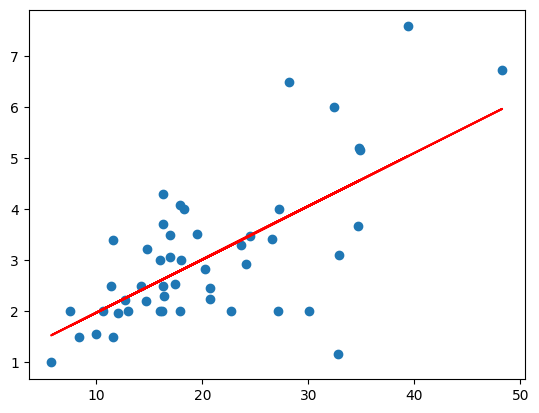

In [16]:
# plot the model and data
plt.scatter(X_test, y_test)
plt.plot(X_test, y_predict, color='red')
plt.show()